# `Лабораторная работа №2`

## Импорт библиотек

In [6]:
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm # Текстовая версия, работает везде

import os
from torch.utils.data import Dataset
from PIL import Image

from torchvision import transforms
from torch.utils.data import DataLoader

import torch.nn.functional as F

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.models as models

import tensorflow as tf
from keras import layers, models, Input
from keras.models import Model
from keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, f1_score

## Подготовка данных

In [13]:
path_to_train = 'Dataset/train'
path_to_test = 'Dataset/test'
path_to_valid = 'Dataset/valid'

def check_counts(split_path):
    images_count = len(os.listdir(os.path.join(split_path, 'images')))
    labels_count = len(os.listdir(os.path.join(split_path, 'labels')))
    print(f"{split_path}: images={images_count}, labels={labels_count}")
    if images_count == labels_count:
        print("OK")
    else:
        print("Ошибка: количество изображений и меток не совпадает")

check_counts(path_to_train)
check_counts(path_to_valid)
check_counts(path_to_test)

Dataset/train: images=18323, labels=18323
OK
Dataset/valid: images=1740, labels=1740
OK
Dataset/test: images=889, labels=889
OK


In [14]:
def check_images(path):
    print(f'Проверка изображений в {path}...')
    broken_found = False

    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
            img.close()
        except Exception:
            print('Broken:', img_name)
            broken_found = True

    if not broken_found:
        print('Все изображения валидны.')
    else:
        print('Есть битые изображения.')

check_images(os.path.join(path_to_train, 'images'))

Проверка изображений в Dataset/train\images...
Все изображения валидны.


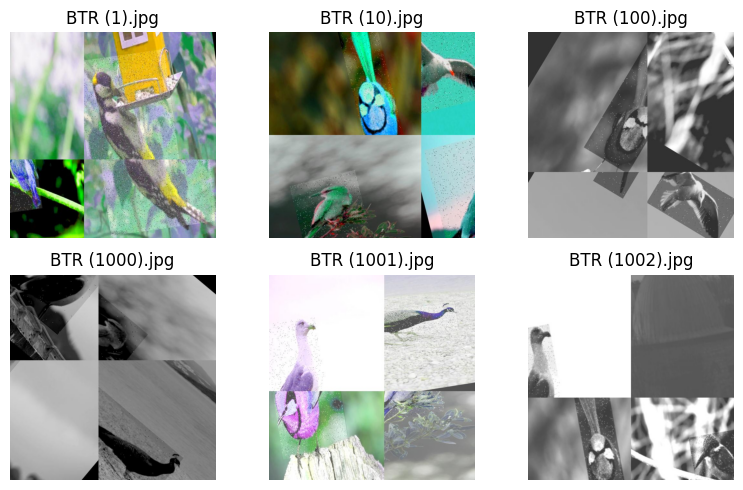

In [15]:
sample_images = os.listdir(os.path.join(path_to_train, 'images'))[:6]
plt.figure(figsize=(8, 5))
for i, img_name in enumerate(sample_images):
    img = Image.open(os.path.join(path_to_train, 'images', img_name))
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [16]:
class BirdDroneDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_names = os.listdir(root_dir)

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        
        # Определяем класс: если в имени есть 'B', то это Bird (0), если 'D' - Drone (1)
        # Судя по твоим скриншотам (BV...), префикс четко говорит о классе.
        label = 1 if img_name.startswith('D') else 0
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [17]:
# Стандартные трансформации для предобученных сетей
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Пути к папкам именно с картинками
train_data = BirdDroneDataset(os.path.join(path_to_train, 'images'), transform=data_transforms)
valid_data = BirdDroneDataset(os.path.join(path_to_valid, 'images'), transform=data_transforms)
test_data = BirdDroneDataset(os.path.join(path_to_test, 'images'), transform=data_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [18]:
name = train_data.image_names[0]
label = 1 if name.startswith('D') else 0
print(f"Файл: {name}, Класс: {label} (1=Drone, 0=Bird)")

Файл: BTR (1).jpg, Класс: 0 (1=Drone, 0=Bird)


## Обучение сверточной нейронной сети (CNN)

In [9]:
class MySimpleCNN(nn.Module):
    def __init__(self):
        super(MySimpleCNN, self).__init__()
        # Первый блок: из 3 каналов (RGB) делаем 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2) # Уменьшает размер в 2 раза
        
        # Второй блок: из 16 в 32 канала
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        
        # Третий блок: из 32 в 64 канала
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        # После 3-х пулингов размер 224 -> 112 -> 56 -> 28
        # Итого имеем 64 карты признаков размером 28x28
        self.fc1 = nn.Linear(64 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, 2) # 2 класса: Bird и Drone

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        x = x.view(-1, 64 * 28 * 28) # "Выпрямляем" в вектор
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Создаем модель
model_cnn = MySimpleCNN()

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cnn = model_cnn.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001)

epochs = 10 

# Списки для хранения истории (чтобы потом построить графики)
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

In [26]:
for epoch in range(epochs):
    # --- ЭТАП ОБУЧЕНИЯ ---
    model_cnn.train()
    
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    # Оборачиваем лоадер в tqdm для прогресс-бара
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
    
    for images, labels in train_loop:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_cnn(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # Статистика
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
        # Обновляем инфо в прогресс-баре (как в Keras)
        train_loop.set_postfix(loss=loss.item(), acc=train_correct/train_total)
    
    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_correct / train_total
    
    # --- ЭТАП ВАЛИДАЦИИ ---
    model_cnn.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    # Для валидации тоже можно добавить бар, если данных много
    val_loop = tqdm(valid_loader, desc=f"Epoch {epoch+1}/{epochs} [Valid]", leave=False)
    
    with torch.no_grad():
        for images, labels in val_loop:
            images, labels = images.to(device), labels.to(device)
            outputs = model_cnn(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    avg_val_loss = val_loss / len(valid_loader)
    avg_val_acc = val_correct / val_total
    
    # Сохраняем в историю для графиков
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_acc'].append(avg_val_acc)
    
    # Итоговый вывод за эпоху
    print(f"Эпоха {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} Acc: {avg_train_acc:.4f} | Val Loss: {avg_val_loss:.4f} Acc: {avg_val_acc:.4f}")

Эпоха 01 | Train Loss: 0.0264 Acc: 0.9902 | Val Loss: 3.4123 Acc: 0.6368


Эпоха 02 | Train Loss: 0.0165 Acc: 0.9942 | Val Loss: 2.7314 Acc: 0.6494


Эпоха 03 | Train Loss: 0.0185 Acc: 0.9933 | Val Loss: 2.4371 Acc: 0.6724


Эпоха 04 | Train Loss: 0.0081 Acc: 0.9972 | Val Loss: 4.6201 Acc: 0.6506


Эпоха 05 | Train Loss: 0.0227 Acc: 0.9932 | Val Loss: 3.3502 Acc: 0.6569


Эпоха 06 | Train Loss: 0.0057 Acc: 0.9982 | Val Loss: 4.6709 Acc: 0.6718


Эпоха 07 | Train Loss: 0.0056 Acc: 0.9986 | Val Loss: 3.5308 Acc: 0.6713


Эпоха 08 | Train Loss: 0.0165 Acc: 0.9945 | Val Loss: 3.0381 Acc: 0.6592


Эпоха 09 | Train Loss: 0.0093 Acc: 0.9973 | Val Loss: 2.5910 Acc: 0.6759


Эпоха 10 | Train Loss: 0.0022 Acc: 0.9996 | Val Loss: 2.7445 Acc: 0.6580


In [27]:
def evaluate_pytorch_model(model, test_loader, history, model_name="CNN_v1"):
    model.eval()
    all_preds = []
    all_labels = []
    
    # 1. Собираем предсказания на тестовых данных
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # 2. Отрисовка графиков обучения (Loss и Accuracy в одном ряду)
    plt.figure(figsize=(15, 5))
    
    # График Loss
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss', linestyle='--')
    plt.title(f'{model_name} — Функция потерь')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # График Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc', linestyle='--')
    plt.title(f'{model_name} — Точность')
    plt.xlabel('Эпоха')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 3. Матрица ошибок (отдельным блоком)
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Bird', 'Drone'], yticklabels=['Bird', 'Drone'])
    plt.title(f'Матрица ошибок — {model_name}')
    plt.ylabel('Истинный класс')
    plt.xlabel('Предсказанный класс')
    plt.show()

    # 4. Вывод текстовых метрик
    print(f"\n--- Отчет для {model_name} ---")
    print(classification_report(all_labels, all_preds, target_names=['Bird', 'Drone']))
    print(f"Accuracy (Точность): {accuracy_score(all_labels, all_preds):.4f}")
    print(f"Recall (Полнота):    {recall_score(all_labels, all_preds):.4f}")
    print(f"F1-score:            {f1_score(all_labels, all_preds, average='weighted'):.4f}")


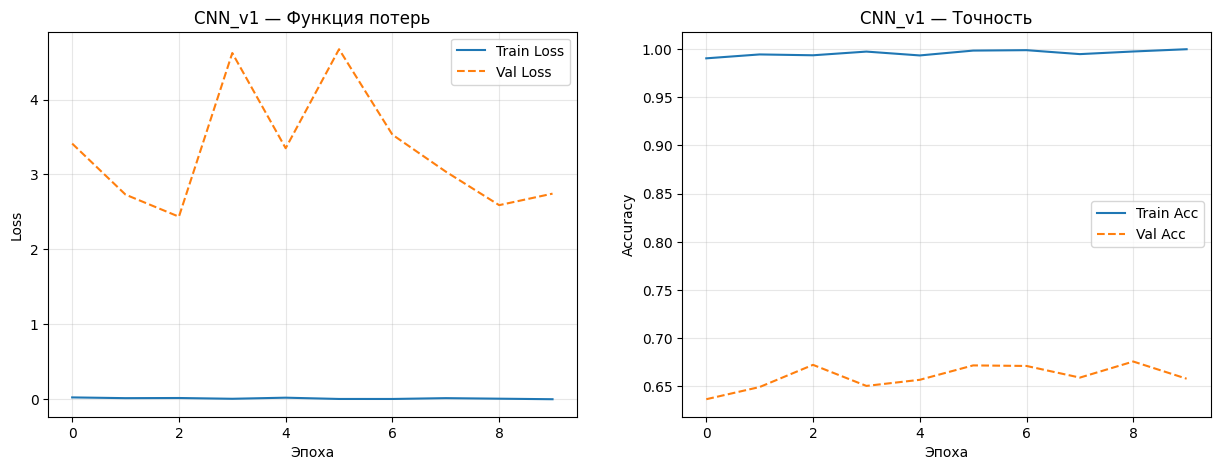

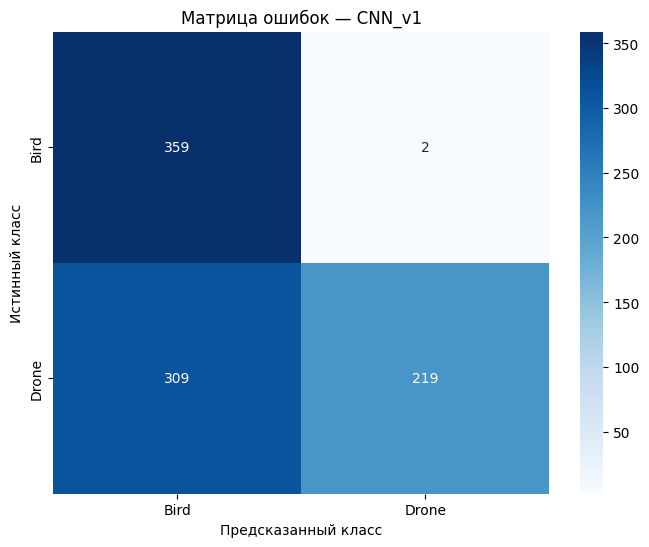


--- Отчет для CNN_v1 ---
              precision    recall  f1-score   support

        Bird       0.54      0.99      0.70       361
       Drone       0.99      0.41      0.58       528

    accuracy                           0.65       889
   macro avg       0.76      0.70      0.64       889
weighted avg       0.81      0.65      0.63       889

Accuracy (Точность): 0.6502
Recall (Полнота):    0.4148
F1-score:            0.6307


In [28]:
# ЗАПУСК ОЦЕНКИ
# Передаем весь словарь history целиком
evaluate_pytorch_model(
    model_cnn, 
    test_loader, 
    history, 
    model_name="CNN_v1"
)

***
## AlexNet

In [11]:
import torchvision.models as models

# Загружаем предобученную AlexNet
model_alexnet = models.alexnet(weights='DEFAULT')

# Замораживаем ВСЕ параметры (Пункт 6: обучение с замороженными слоями)
for param in model_alexnet.parameters():
    param.requires_grad = False

# Меняем последний слой классификатора (там 4096 входов) на 2 выхода
model_alexnet.classifier[6] = nn.Linear(4096, 2)

model_alexnet = model_alexnet.to(device)

# Оптимизатор только для размороженного слоя
optimizer_alex = optim.Adam(model_alexnet.classifier[6].parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# История для графиков AlexNet
history_alex = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

In [19]:
epochs = 5 

for epoch in range(epochs):
    # --- ЭТАП ОБУЧЕНИЯ ---
    model_alexnet.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    train_loop = tqdm(train_loader, desc=f"AlexNet Frozen Ep {epoch+1}", leave=False)
    
    for images, labels in train_loop:
        images, labels = images.to(device), labels.to(device)
        optimizer_alex.zero_grad()
        outputs = model_alexnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_alex.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        train_loop.set_postfix(loss=loss.item(), acc=train_correct/train_total)

    # --- ЭТАП ВАЛИДАЦИИ ---
    model_alexnet.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_alexnet(images)
            v_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            v_total += labels.size(0)
            v_correct += (predicted == labels).sum().item()

    # РАСЧЕТ МЕТРИК ДЛЯ ТЕКУЩЕЙ ЭПОХИ (Поправка здесь)
    curr_train_loss = train_loss / len(train_loader)
    curr_train_acc = train_correct / train_total
    curr_val_loss = v_loss / len(valid_loader)
    curr_val_acc = v_correct / v_total

    # Сохраняем в историю
    history_alex['train_loss'].append(curr_train_loss)
    history_alex['val_loss'].append(curr_val_loss)
    history_alex['train_acc'].append(curr_train_acc)
    history_alex['val_acc'].append(curr_val_acc)
    
    # ПЕЧАТЬ (используем актуальные переменные curr_...)
    print(f"Эпоха {epoch+1:02d} | Train Loss: {curr_train_loss:.4f} Acc: {curr_train_acc:.4f} | Val Loss: {curr_val_loss:.4f} Acc: {curr_val_acc:.4f}")

Эпоха 01 | Train Loss: 0.0359 Acc: 0.9871 | Val Loss: 0.4250 Acc: 0.8483


Эпоха 02 | Train Loss: 0.0214 Acc: 0.9915 | Val Loss: 0.2040 Acc: 0.9132


Эпоха 03 | Train Loss: 0.0167 Acc: 0.9936 | Val Loss: 0.5439 Acc: 0.8431


Эпоха 04 | Train Loss: 0.0196 Acc: 0.9937 | Val Loss: 0.6732 Acc: 0.8310


Эпоха 05 | Train Loss: 0.0151 Acc: 0.9946 | Val Loss: 0.5078 Acc: 0.8678


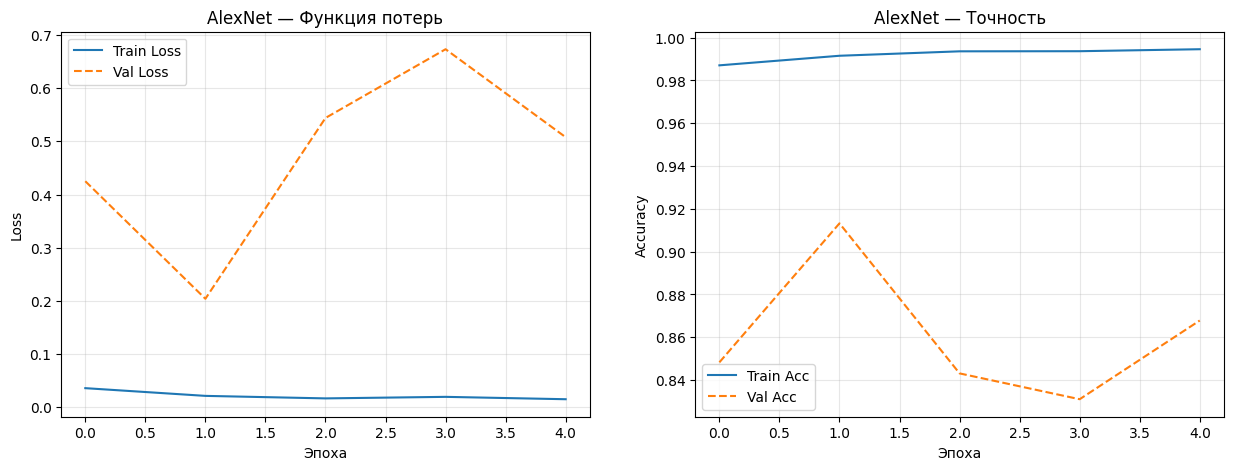

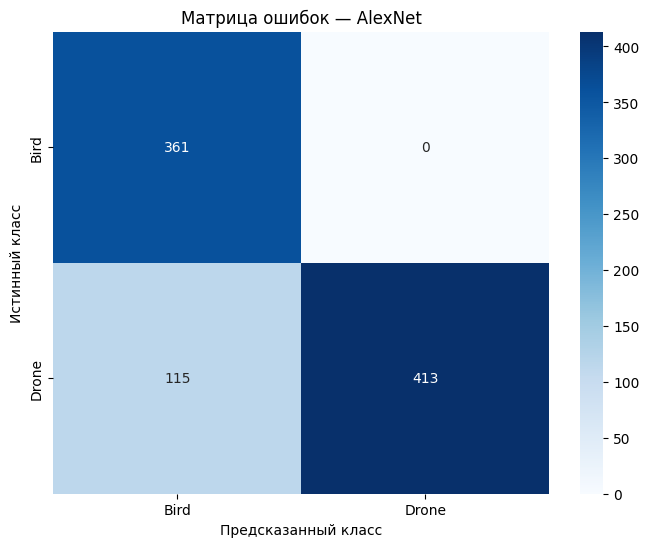


--- Отчет для AlexNet ---
              precision    recall  f1-score   support

        Bird       0.76      1.00      0.86       361
       Drone       1.00      0.78      0.88       528

    accuracy                           0.87       889
   macro avg       0.88      0.89      0.87       889
weighted avg       0.90      0.87      0.87       889

Accuracy (Точность): 0.8706
Recall (Полнота):    0.7822
F1-score:            0.8716


In [23]:
evaluate_pytorch_model(
    model_alexnet, 
    test_loader, 
    history_alex, 
    model_name="AlexNet"
)

In [29]:
# Настройка Fine-tuning
for i in range(3, 7):
    for param in model_alexnet.classifier[i].parameters():
        param.requires_grad = True

# Уменьшаем Learning Rate (шаг обучения), чтобы не "сломать" веса
optimizer_finetune = optim.Adam(filter(lambda p: p.requires_grad, model_alexnet.parameters()), lr=0.0001)

fine_tune_epochs = 5 # Обычно хватает 3-5 эпох для дообучения

for epoch in range(fine_tune_epochs):
    # --- ЭТАП ОБУЧЕНИЯ (Fine-tuning) ---
    model_alexnet.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    # Меняем описание в tqdm, чтобы видеть, что идет дообучение
    train_loop = tqdm(train_loader, desc=f"AlexNet Fine-Tune Ep {epoch+1}", leave=False)
    
    for images, labels in train_loop:
        images, labels = images.to(device), labels.to(device)
        
        # ВАЖНО: Используем optimizer_finetune!
        optimizer_finetune.zero_grad()
        outputs = model_alexnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_finetune.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        train_loop.set_postfix(loss=loss.item(), acc=train_correct/train_total)

    # --- ЭТАП ВАЛИДАЦИИ ---
    model_alexnet.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_alexnet(images)
            v_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            v_total += labels.size(0)
            v_correct += (predicted == labels).sum().item()

    # Считаем метрики для текущей эпохи дообучения
    curr_train_loss = train_loss / len(train_loader)
    curr_train_acc = train_correct / train_total
    curr_val_loss = v_loss / len(valid_loader)
    curr_val_acc = v_correct / v_total

    # Дописываем в ту же историю history_alex
    history_alex['train_loss'].append(curr_train_loss)
    history_alex['val_loss'].append(curr_val_loss)
    history_alex['train_acc'].append(curr_train_acc)
    history_alex['val_acc'].append(curr_val_acc)
    
    print(f"Fine-Tune Эпоха {epoch+1:02d} | Train Loss: {curr_train_loss:.4f} Acc: {curr_train_acc:.4f} | Val Loss: {curr_val_loss:.4f} Acc: {curr_val_acc:.4f}")

Fine-Tune Эпоха 01 | Train Loss: 0.0357 Acc: 0.9930 | Val Loss: 1.4045 Acc: 0.8724


Fine-Tune Эпоха 02 | Train Loss: 0.0304 Acc: 0.9948 | Val Loss: 0.5804 Acc: 0.9213


Fine-Tune Эпоха 03 | Train Loss: 0.0225 Acc: 0.9957 | Val Loss: 0.7469 Acc: 0.9057


Fine-Tune Эпоха 04 | Train Loss: 0.0221 Acc: 0.9965 | Val Loss: 1.2872 Acc: 0.8184


Fine-Tune Эпоха 05 | Train Loss: 0.0231 Acc: 0.9961 | Val Loss: 0.4031 Acc: 0.9523


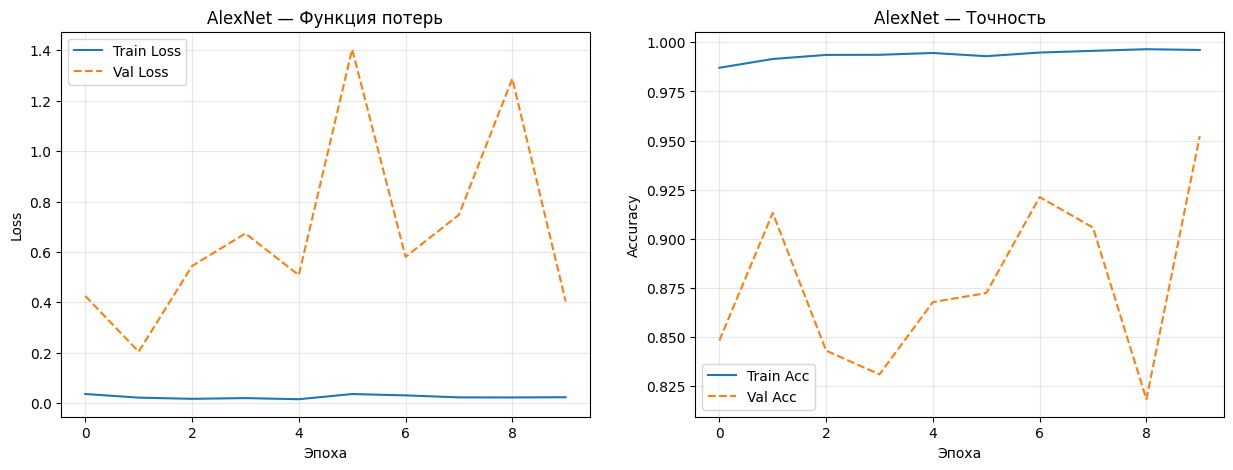

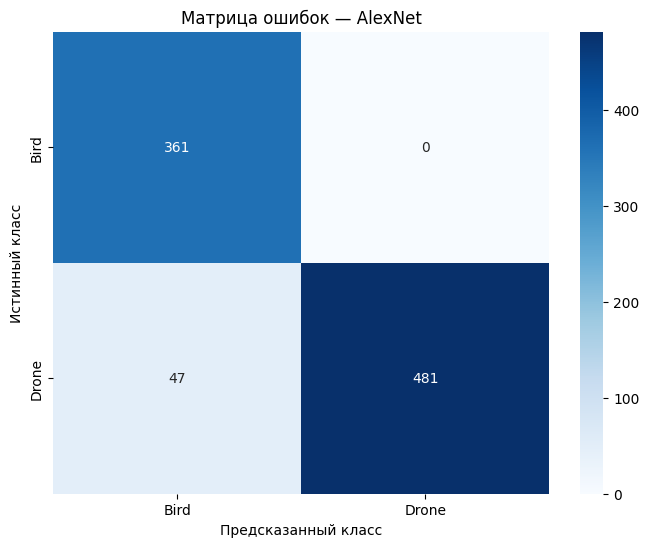


--- Отчет для AlexNet ---
              precision    recall  f1-score   support

        Bird       0.88      1.00      0.94       361
       Drone       1.00      0.91      0.95       528

    accuracy                           0.95       889
   macro avg       0.94      0.96      0.95       889
weighted avg       0.95      0.95      0.95       889

Accuracy (Точность): 0.9471
Recall (Полнота):    0.9110
F1-score:            0.9475


In [30]:
evaluate_pytorch_model(
    model_alexnet, 
    test_loader, 
    history_alex, 
    model_name="AlexNet"
)

***
## ResNet34

In [31]:
import torchvision.models as models

# Загружаем ResNet34
model_resnet = models.resnet34(weights='DEFAULT')

# Замораживаем слои (Пункт 6)
for param in model_resnet.parameters():
    param.requires_grad = False

# Заменяем финальный слой fc (у ResNet34 на входе 512 нейронов)
num_ftrs = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_ftrs, 2)

model_resnet = model_resnet.to(device)

# Оптимизатор только для нового слоя
optimizer_res = optim.Adam(model_resnet.fc.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# История для графиков
history_res = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

In [32]:
epochs = 5 

for epoch in range(epochs):
    # --- ЭТАП ОБУЧЕНИЯ (Frozen) ---
    model_resnet.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    train_loop = tqdm(train_loader, desc=f"ResNet Frozen Ep {epoch+1}", leave=False)
    
    for images, labels in train_loop:
        images, labels = images.to(device), labels.to(device)
        
        optimizer_res.zero_grad()
        outputs = model_resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_res.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        train_loop.set_postfix(loss=loss.item(), acc=train_correct/train_total)

    # --- ЭТАП ВАЛИДАЦИИ ---
    model_resnet.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_resnet(images)
            v_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            v_total += labels.size(0)
            v_correct += (predicted == labels).sum().item()

    # Метрики
    curr_train_loss = train_loss / len(train_loader)
    curr_train_acc = train_correct / train_total
    curr_val_loss = v_loss / len(valid_loader)
    curr_val_acc = v_correct / v_total

    history_res['train_loss'].append(curr_train_loss)
    history_res['val_loss'].append(curr_val_loss)
    history_res['train_acc'].append(curr_train_acc)
    history_res['val_acc'].append(curr_val_acc)
    
    print(f"ResNet Frozen Ep {epoch+1:02d} | Train Loss: {curr_train_loss:.4f} Acc: {curr_train_acc:.4f} | Val Loss: {curr_val_loss:.4f} Acc: {curr_val_acc:.4f}")

ResNet Frozen Ep 01 | Train Loss: 0.0748 Acc: 0.9782 | Val Loss: 0.2474 Acc: 0.8862


ResNet Frozen Ep 02 | Train Loss: 0.0249 Acc: 0.9932 | Val Loss: 0.1694 Acc: 0.9368


ResNet Frozen Ep 03 | Train Loss: 0.0166 Acc: 0.9952 | Val Loss: 0.2864 Acc: 0.8833


ResNet Frozen Ep 04 | Train Loss: 0.0140 Acc: 0.9957 | Val Loss: 0.2258 Acc: 0.9172


ResNet Frozen Ep 05 | Train Loss: 0.0173 Acc: 0.9937 | Val Loss: 0.1389 Acc: 0.9420


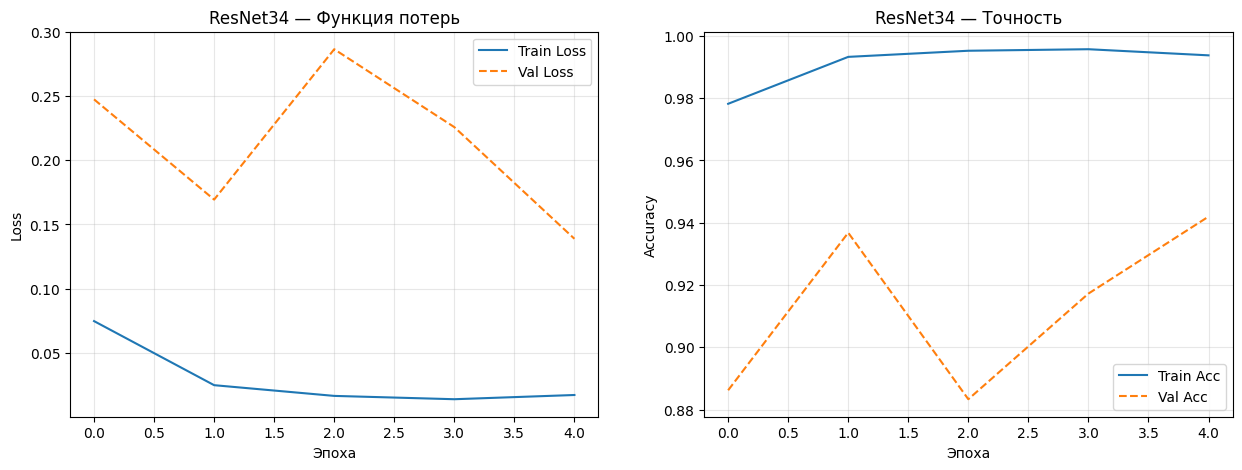

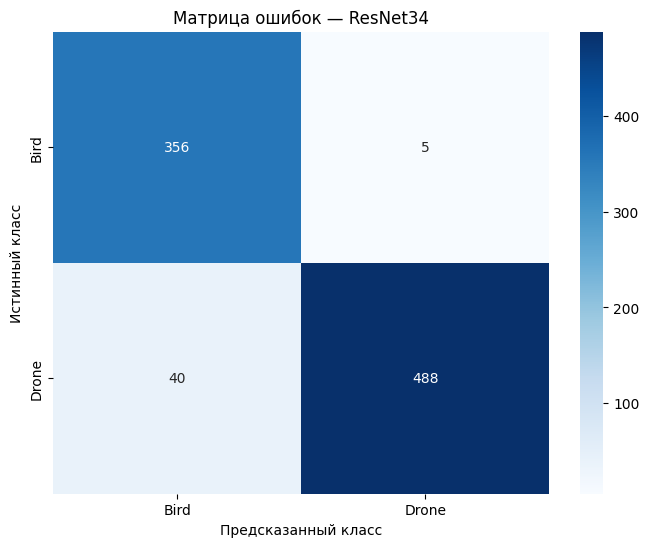


--- Отчет для ResNet34 ---
              precision    recall  f1-score   support

        Bird       0.90      0.99      0.94       361
       Drone       0.99      0.92      0.96       528

    accuracy                           0.95       889
   macro avg       0.94      0.96      0.95       889
weighted avg       0.95      0.95      0.95       889

Accuracy (Точность): 0.9494
Recall (Полнота):    0.9242
F1-score:            0.9497


In [33]:
# Запуск оценки для ResNet34
evaluate_pytorch_model(
    model_resnet, 
    test_loader, 
    history_res, # Передаем словарь истории ResNet
    model_name="ResNet34"
)

In [34]:
# Чтобы разморозить последние слои перед дообучением:
for param in model_resnet.layer4.parameters():
    param.requires_grad = True

# И не забудь обновить оптимизатор на меньший lr
optimizer_res_finetune = optim.Adam(filter(lambda p: p.requires_grad, model_resnet.parameters()), lr=0.0001)

In [35]:
fine_tune_epochs = 5 

for epoch in range(fine_tune_epochs):
    # --- ЭТАП ОБУЧЕНИЯ (Fine-tuning) ---
    model_resnet.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    train_loop = tqdm(train_loader, desc=f"ResNet Fine-Tune Ep {epoch+1}", leave=False)
    
    for images, labels in train_loop:
        images, labels = images.to(device), labels.to(device)
        
        # Используем НОВЫЙ оптимизатор optimizer_res_finetune
        optimizer_res_finetune.zero_grad()
        outputs = model_resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_res_finetune.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        train_loop.set_postfix(loss=loss.item(), acc=train_correct/train_total)

    # --- ЭТАП ВАЛИДАЦИИ ---
    model_resnet.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_resnet(images)
            v_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            v_total += labels.size(0)
            v_correct += (predicted == labels).sum().item()

    # Метрики
    curr_train_loss = train_loss / len(train_loader)
    curr_train_acc = train_correct / train_total
    curr_val_loss = v_loss / len(valid_loader)
    curr_val_acc = v_correct / v_total

    # Дописываем в ту же историю history_res
    history_res['train_loss'].append(curr_train_loss)
    history_res['val_loss'].append(curr_val_loss)
    history_res['train_acc'].append(curr_train_acc)
    history_res['val_acc'].append(curr_val_acc)
    
    print(f"ResNet FT Ep {epoch+1:02d} | Train Loss: {curr_train_loss:.4f} Acc: {curr_train_acc:.4f} | Val Loss: {curr_val_loss:.4f} Acc: {curr_val_acc:.4f}")

ResNet FT Ep 01 | Train Loss: 0.0118 Acc: 0.9966 | Val Loss: 0.0258 Acc: 0.9874


ResNet FT Ep 02 | Train Loss: 0.0012 Acc: 0.9997 | Val Loss: 0.0353 Acc: 0.9839


ResNet FT Ep 03 | Train Loss: 0.0024 Acc: 0.9994 | Val Loss: 0.1691 Acc: 0.9115


ResNet FT Ep 04 | Train Loss: 0.0012 Acc: 0.9997 | Val Loss: 0.0175 Acc: 0.9908


ResNet FT Ep 05 | Train Loss: 0.0001 Acc: 1.0000 | Val Loss: 0.0484 Acc: 0.9782


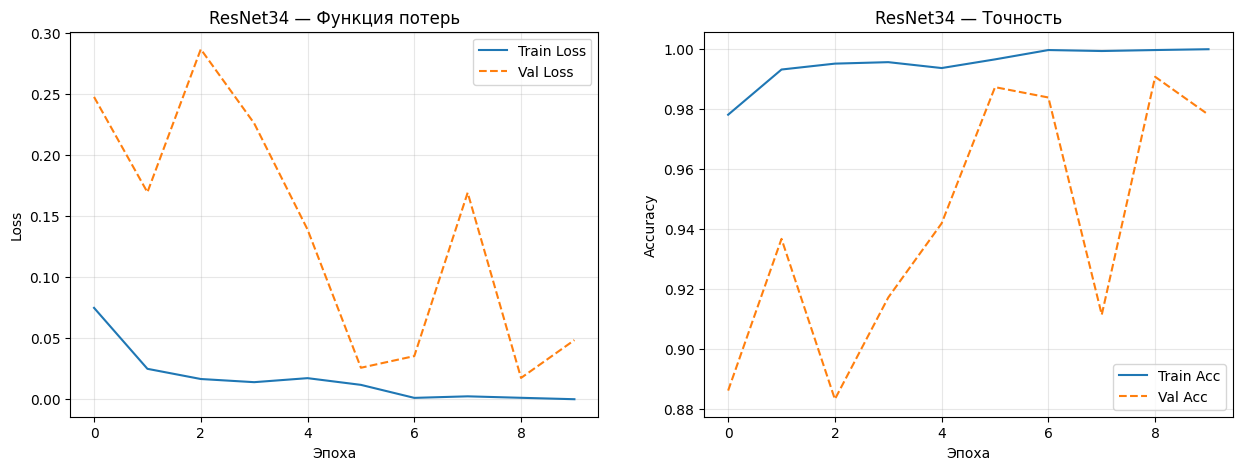

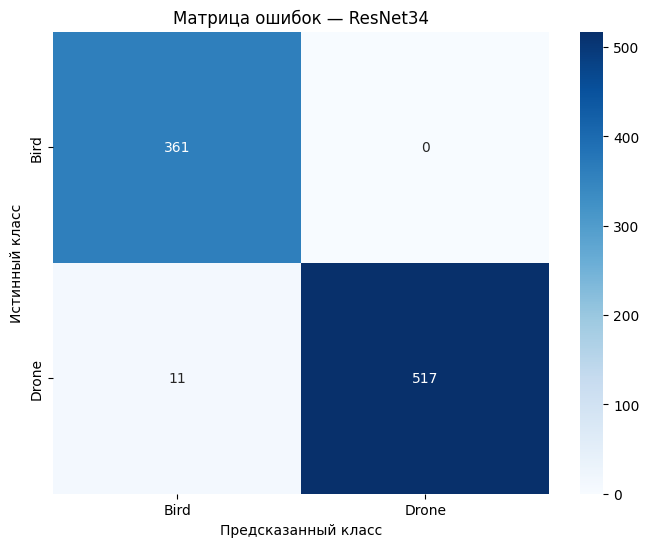


--- Отчет для ResNet34 ---
              precision    recall  f1-score   support

        Bird       0.97      1.00      0.98       361
       Drone       1.00      0.98      0.99       528

    accuracy                           0.99       889
   macro avg       0.99      0.99      0.99       889
weighted avg       0.99      0.99      0.99       889

Accuracy (Точность): 0.9876
Recall (Полнота):    0.9792
F1-score:            0.9877


In [36]:
# Запуск оценки для ResNet34
evaluate_pytorch_model(
    model_resnet, 
    test_loader, 
    history_res, # Передаем словарь истории ResNet
    model_name="ResNet34"
)

***
## EfficientNet-B2

In [37]:
import torchvision.models as models

# Загружаем EfficientNet-B2
model_eff = models.efficientnet_b2(weights='DEFAULT')

# Замораживаем веса (Пункт 6)
for param in model_eff.parameters():
    param.requires_grad = False

# У EfficientNet-B2 вход классификатора имеет 1408 нейронов
num_ftrs = model_eff.classifier[1].in_features
model_eff.classifier[1] = nn.Linear(num_ftrs, 2)

model_eff = model_eff.to(device)

# Оптимизатор и история
optimizer_eff = optim.Adam(model_eff.classifier[1].parameters(), lr=0.001)
history_eff = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

In [39]:
epochs = 3 

for epoch in range(epochs):
    # --- ЭТАП ОБУЧЕНИЯ (Frozen) ---
    model_eff.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    train_loop = tqdm(train_loader, desc=f"EffNet Frozen Ep {epoch+1}", leave=False)
    
    for images, labels in train_loop:
        images, labels = images.to(device), labels.to(device)
        
        optimizer_eff.zero_grad()
        outputs = model_eff(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_eff.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        train_loop.set_postfix(loss=loss.item(), acc=train_correct/train_total)

    # --- ЭТАП ВАЛИДАЦИИ ---
    model_eff.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_eff(images)
            v_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            v_total += labels.size(0)
            v_correct += (predicted == labels).sum().item()

    # Метрики текущей эпохи
    curr_train_loss = train_loss / len(train_loader)
    curr_train_acc = train_correct / train_total
    curr_val_loss = v_loss / len(valid_loader)
    curr_val_acc = v_correct / v_total

    history_eff['train_loss'].append(curr_train_loss)
    history_eff['val_loss'].append(curr_val_loss)
    history_eff['train_acc'].append(curr_train_acc)
    history_eff['val_acc'].append(curr_val_acc)
    
    print(f"EffNet Frozen Ep {epoch+1:02d} | Train Loss: {curr_train_loss:.4f} Acc: {curr_train_acc:.4f} | Val Loss: {curr_val_loss:.4f} Acc: {curr_val_acc:.4f}")

EffNet Frozen Ep 01 | Train Loss: 0.0562 Acc: 0.9850 | Val Loss: 0.1417 Acc: 0.9638


EffNet Frozen Ep 02 | Train Loss: 0.0428 Acc: 0.9866 | Val Loss: 0.1895 Acc: 0.9414


EffNet Frozen Ep 03 | Train Loss: 0.0390 Acc: 0.9874 | Val Loss: 0.1482 Acc: 0.9546


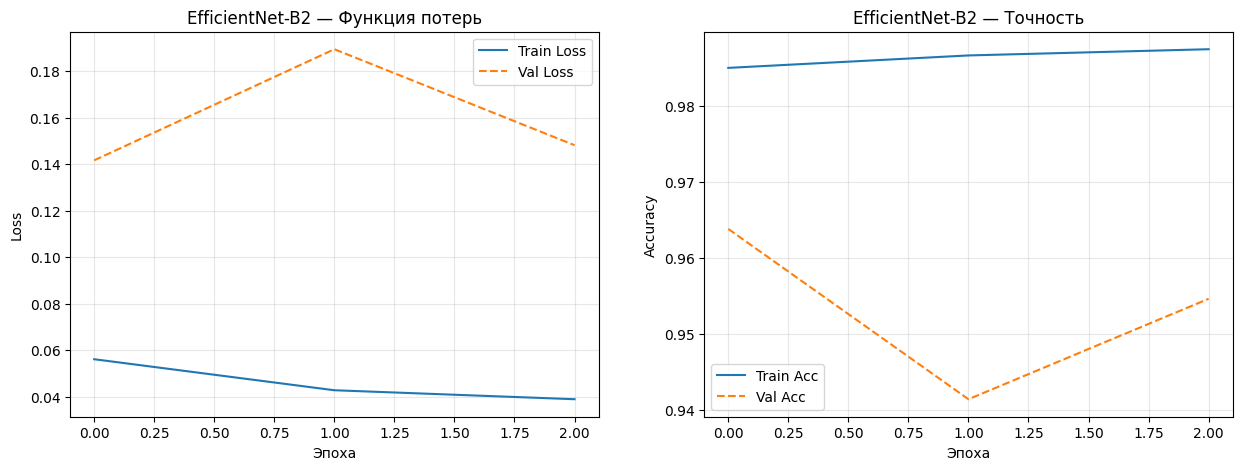

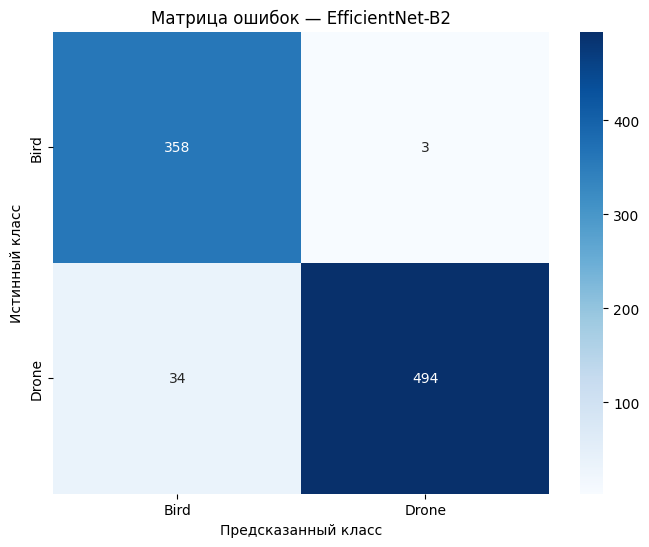


--- Отчет для EfficientNet-B2 ---
              precision    recall  f1-score   support

        Bird       0.91      0.99      0.95       361
       Drone       0.99      0.94      0.96       528

    accuracy                           0.96       889
   macro avg       0.95      0.96      0.96       889
weighted avg       0.96      0.96      0.96       889

Accuracy (Точность): 0.9584
Recall (Полнота):    0.9356
F1-score:            0.9586


In [40]:
# Один вызов — все графики и метрики сразу
evaluate_pytorch_model(
    model_eff, 
    test_loader, 
    history_eff, 
    model_name="EfficientNet-B2"
)

In [41]:
# Разморозка всего классификатора для fine-tuning
for param in model_eff.classifier.parameters():
    param.requires_grad = True

# Новый оптимизатор с низким lr
optimizer_eff_fine = optim.Adam(filter(lambda p: p.requires_grad, model_eff.parameters()), lr=0.0001)

In [42]:
fine_tune_epochs = 3 

for epoch in range(fine_tune_epochs):
    # --- ЭТАП ОБУЧЕНИЯ (Fine-tuning) ---
    model_eff.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    train_loop = tqdm(train_loader, desc=f"EffNet Fine-Tune Ep {epoch+1}", leave=False)
    
    for images, labels in train_loop:
        images, labels = images.to(device), labels.to(device)
        
        # ВАЖНО: Используем НОВЫЙ оптимизатор optimizer_eff_fine
        optimizer_eff_fine.zero_grad()
        outputs = model_eff(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_eff_fine.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        train_loop.set_postfix(loss=loss.item(), acc=train_correct/train_total)

    # --- ЭТАП ВАЛИДАЦИИ ---
    model_eff.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_eff(images)
            v_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            v_total += labels.size(0)
            v_correct += (predicted == labels).sum().item()

    # Метрики
    curr_train_loss = train_loss / len(train_loader)
    curr_train_acc = train_correct / train_total
    curr_val_loss = v_loss / len(valid_loader)
    curr_val_acc = v_correct / v_total

    # Дописываем в историю history_eff
    history_eff['train_loss'].append(curr_train_loss)
    history_eff['val_loss'].append(curr_val_loss)
    history_eff['train_acc'].append(curr_train_acc)
    history_eff['val_acc'].append(curr_val_acc)
    
    print(f"EffNet FT Ep {epoch+1:02d} | Train Loss: {curr_train_loss:.4f} Acc: {curr_train_acc:.4f} | Val Loss: {curr_val_loss:.4f} Acc: {curr_val_acc:.4f}")

EffNet FT Ep 01 | Train Loss: 0.0354 Acc: 0.9883 | Val Loss: 0.1526 Acc: 0.9546


EffNet FT Ep 02 | Train Loss: 0.0376 Acc: 0.9871 | Val Loss: 0.1384 Acc: 0.9644


EffNet FT Ep 03 | Train Loss: 0.0345 Acc: 0.9883 | Val Loss: 0.1597 Acc: 0.9523


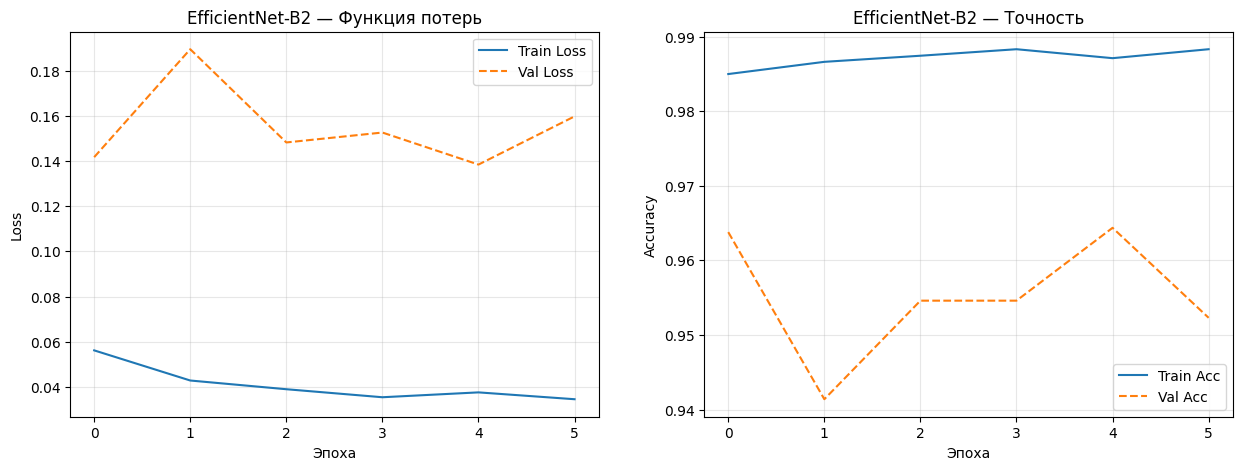

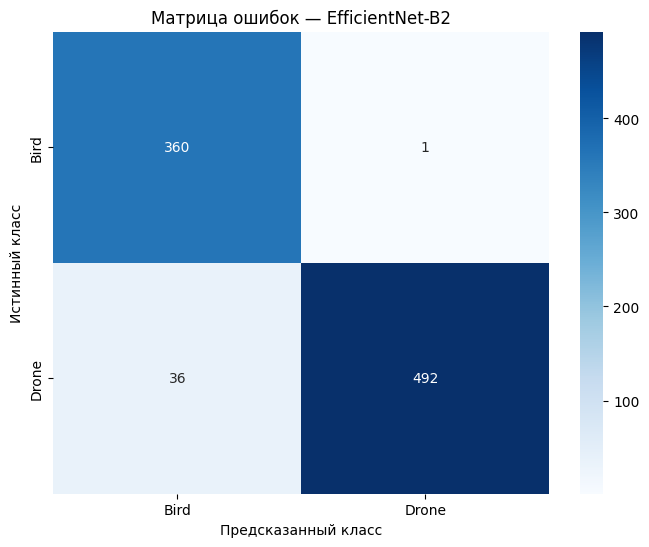


--- Отчет для EfficientNet-B2 ---
              precision    recall  f1-score   support

        Bird       0.91      1.00      0.95       361
       Drone       1.00      0.93      0.96       528

    accuracy                           0.96       889
   macro avg       0.95      0.96      0.96       889
weighted avg       0.96      0.96      0.96       889

Accuracy (Точность): 0.9584
Recall (Полнота):    0.9318
F1-score:            0.9586


In [43]:
# Один вызов — все графики и метрики сразу
evaluate_pytorch_model(
    model_eff, 
    test_loader, 
    history_eff, 
    model_name="EfficientNet-B2"
)